Customer Retention & Churn Analysis
Future Interns - Data Science & Analytics Task 2
Project: Telecom Customer Churn Analysis and Prediction
Objective: Analyze customer behavior, identify churn drivers, build a churn prediction model, and provide business recommendations for customer retention

1. Business Problem
Customer churn occurs when customers stop using a company's service. For telecom companies, churn directly reduces revenue and increases acquisition costs because replacing a lost customer is usually more expensive than retaining an existing one.
The goal of this project is to:
Understand customer churn patterns.
Identify high-risk customer groups.
Analyze usage, plan, revenue, and service behavior.
Build a machine learning model to predict churn.
Recommend retention strategies based on data insights.

In [105]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [106]:
df = pd.read_csv("telecom_churn.csv")
df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [107]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Rows and columns: (3333, 11)

Column names:
['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage', 'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee', 'RoamMins']


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [109]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Churn,3333.0,0.144914,0.352067,0.0,0.00,0.00,0.00,1.00
AccountWeeks,3333.0,101.064806,39.822106,1.0,74.00,101.00,127.00,243.00
ContractRenewal,3333.0,0.903090,0.295879,0.0,1.00,1.00,1.00,1.00
DataPlan,3333.0,0.276628,0.447398,0.0,0.00,0.00,1.00,1.00
DataUsage,3333.0,0.816475,1.272668,0.0,0.00,0.00,1.78,5.40
CustServCalls,3333.0,1.562856,1.315491,0.0,1.00,1.00,2.00,9.00
DayMins,3333.0,179.775098,54.467389,0.0,143.70,179.40,216.40,350.80
DayCalls,3333.0,100.435644,20.069084,0.0,87.00,101.00,114.00,165.00
MonthlyCharge,3333.0,56.305161,16.426032,14.0,45.00,53.50,66.20,111.30
OverageFee,3333.0,10.051488,2.535712,0.0,8.33,10.07,11.77,18.19


In [110]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace(".", "", regex=False)
)

df.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [111]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

Churn              0
AccountWeeks       0
ContractRenewal    0
DataPlan           0
DataUsage          0
CustServCalls      0
DayMins            0
DayCalls           0
MonthlyCharge      0
OverageFee         0
RoamMins           0
dtype: int64

In [112]:
duplicate_count = df.duplicated().sum()
print("Duplicate records:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

Duplicate records: 0


In [113]:
print("Unique values in object columns:")
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}:")
    print(df[col].value_counts())

Unique values in object columns:


In [114]:
possible_churn_cols = [col for col in df.columns if col.lower() == "churn"]
target_col = possible_churn_cols[0] if possible_churn_cols else "Churn"

print("Target column:", target_col)
print(df[target_col].value_counts())

Target column: Churn
Churn
0    2850
1     483
Name: count, dtype: int64


In [115]:
if df[target_col].dtype == "object":
    df[target_col] = df[target_col].map({
        "False": 0, "True": 1,
        "No": 0, "Yes": 1,
        "false": 0, "true": 1,
        "no": 0, "yes": 1
    }).fillna(df[target_col])

if df[target_col].dtype == "bool":
    df[target_col] = df[target_col].astype(int)

df[target_col].value_counts()

Churn
0    2850
1     483
Name: count, dtype: int64

In [116]:
total_customers = len(df)
churned_customers = int(df[target_col].sum())
active_customers = total_customers - churned_customers
churn_rate = churned_customers / total_customers * 100
retention_rate = 100 - churn_rate

print("Total Customers:", total_customers)
print("Active Customers:", active_customers)
print("Churned Customers:", churned_customers)
print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Retention Rate: {retention_rate:.2f}%")

Total Customers: 3333
Active Customers: 2850
Churned Customers: 483
Churn Rate: 14.49%
Retention Rate: 85.51%


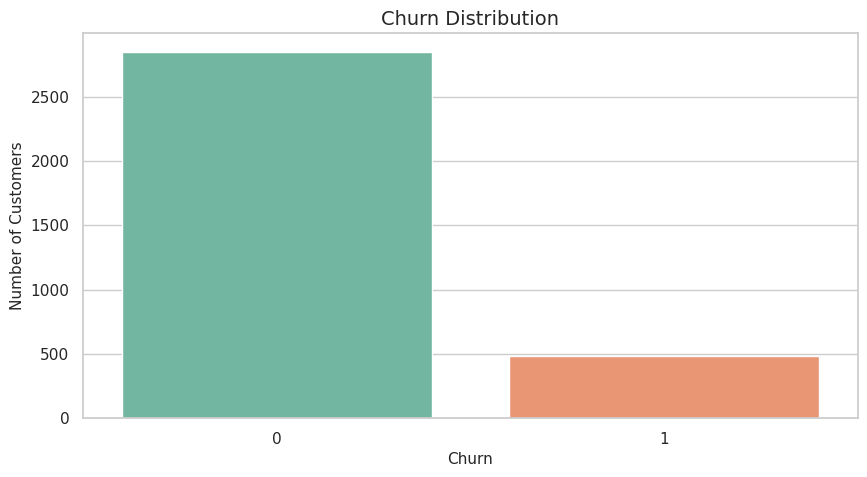

In [117]:
sns.countplot(data=df, x=target_col, palette="Set2")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

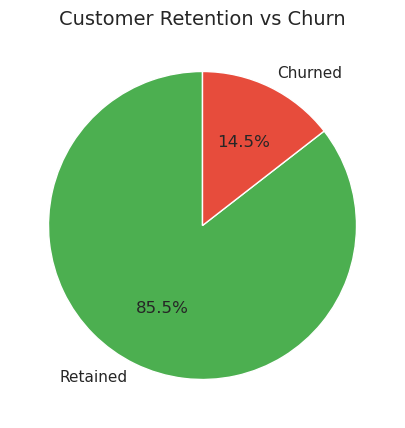

In [118]:
plt.pie(
    [active_customers, churned_customers],
    labels=["Retained", "Churned"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4CAF50", "#E74C3C"]
)
plt.title("Customer Retention vs Churn")
plt.show()

In [132]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)

Numeric columns: ['Churn', 'AccountWeeks', 'ContractRenewal', 'DataPlan', 'DataUsage', 'CustServCalls', 'DayMins', 'DayCalls', 'MonthlyCharge', 'OverageFee', 'RoamMins']

Categorical columns: []


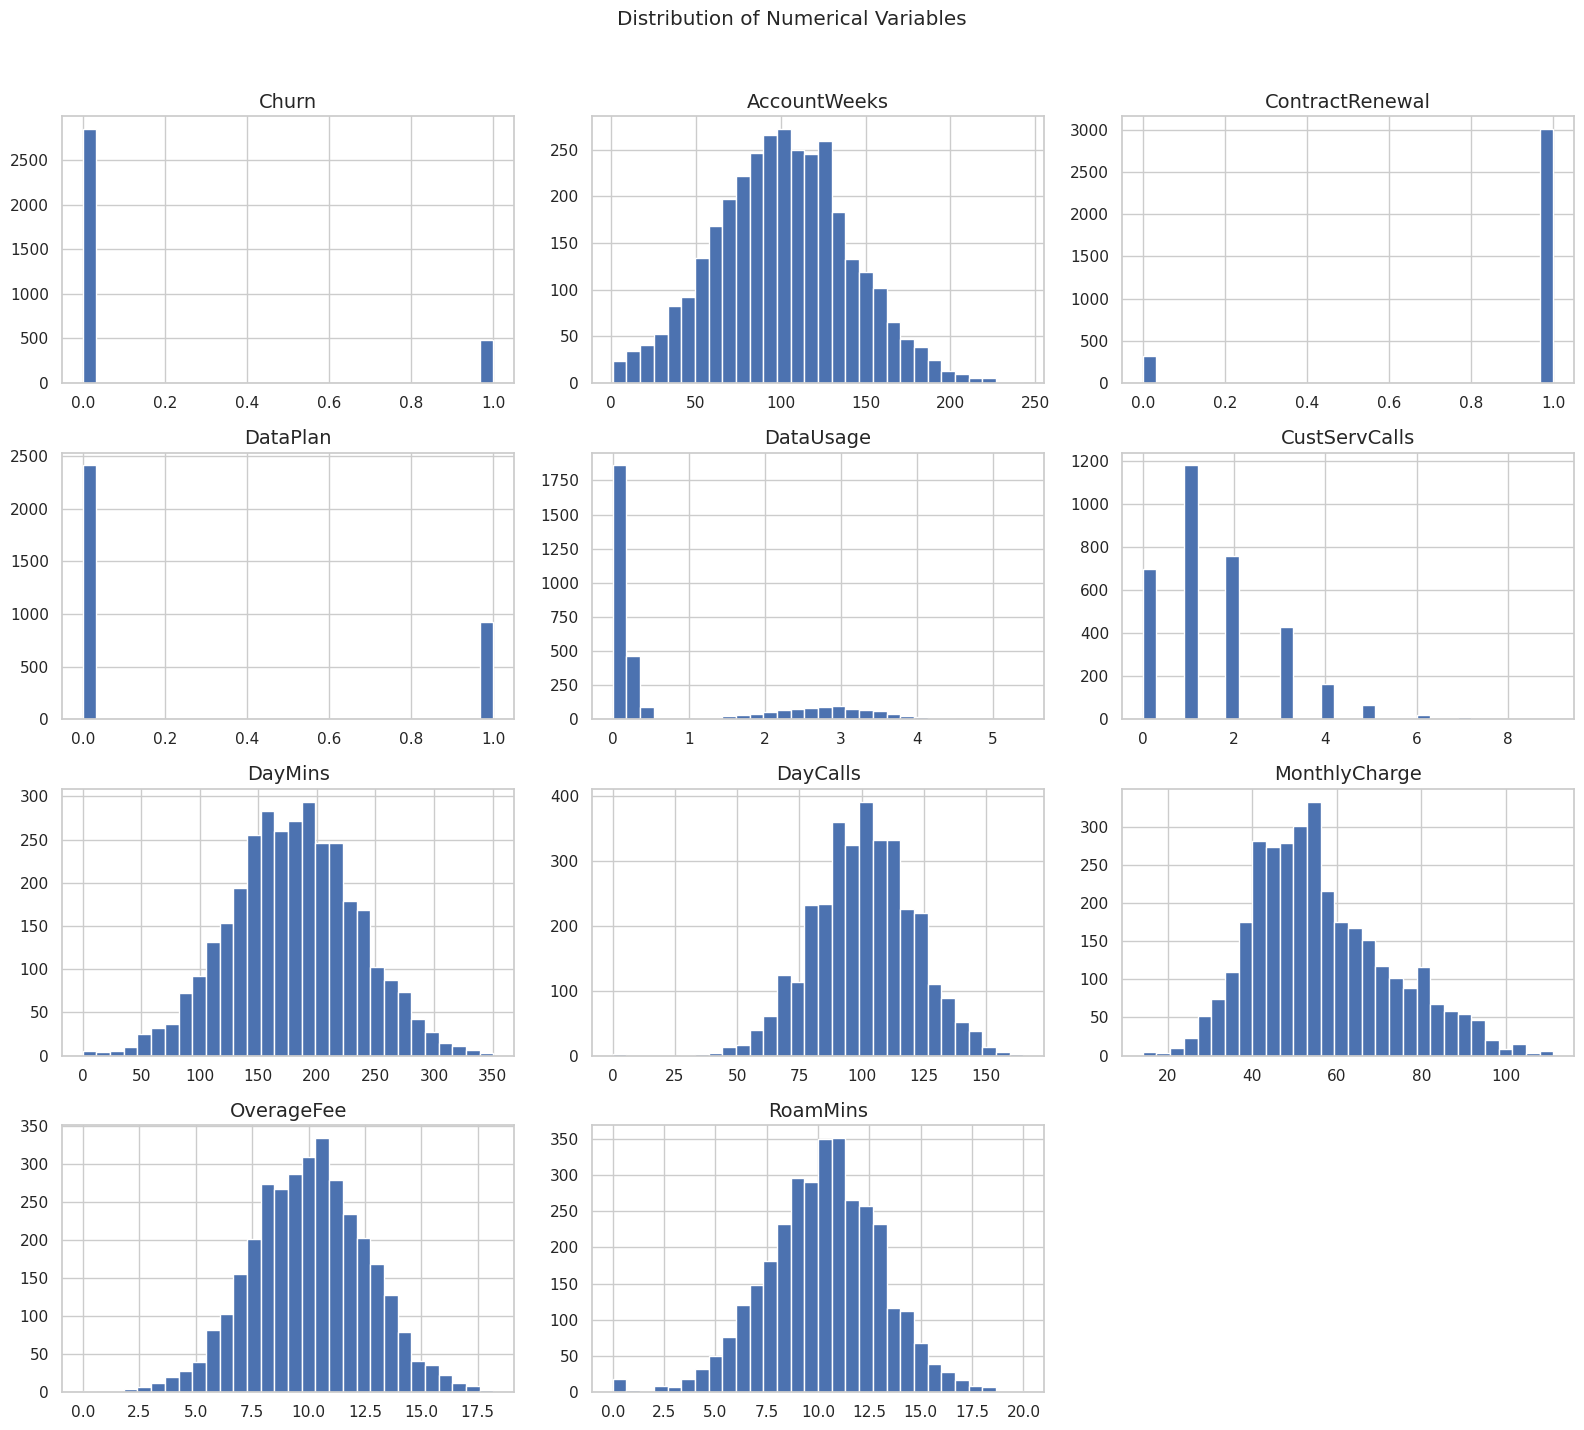

In [133]:
df[numeric_cols].hist(figsize=(16, 14), bins=30)
plt.suptitle("Distribution of Numerical Variables", y=1.02)
plt.tight_layout()
plt.show()

In [134]:
for col in ["Area_Code", "International_Plan", "Voice_Mail_Plan"]:
    if col in df.columns:
        sns.countplot(data=df, x=col, hue=target_col, palette="Set2")
        plt.title(f"Churn by {col}")
        plt.xticks(rotation=30)
        plt.show()

In [135]:
usage_cols = [
    "Total_Day_Minutes", "Total_Eve_Minutes", "Total_Night_Minutes", "Total_Intl_Minutes",
    "total_day_minutes", "total_eve_minutes", "total_night_minutes", "total_intl_minutes"
]
usage_cols = [col for col in usage_cols if col in df.columns]

usage_cols

[]

In [181]:
for col in usage_cols:
    sns.boxplot(data=df, x=target_col, y=col, palette="Set2")
    plt.title(f"{col} by Churn")
    plt.show()

In [137]:
call_cols = [
    "Total_Day_Calls", "Total_Eve_Calls", "Total_Night_Calls", "Total_Intl_Calls",
    "total_day_calls", "total_eve_calls", "total_night_calls", "total_intl_calls"
]
call_cols = [col for col in call_cols if col in df.columns]

for col in call_cols:
    sns.boxplot(data=df, x=target_col, y=col, palette="Set3")
    plt.title(f"{col} by Churn")
    plt.show()

In [152]:
call_cols = [
    "Total_Day_Calls", "Total_Eve_Calls", "Total_Night_Calls", "Total_Intl_Calls",
    "total_day_calls", "total_eve_calls", "total_night_calls", "total_intl_calls"
]
call_cols = [col for col in call_cols if col in df.columns]

for col in call_cols:
    sns.boxplot(data=df, x=target_col, y=col, palette="Set3")
    plt.title(f"{col} by Churn")
    plt.show()

In [153]:
charge_cols = [
    "Total_Day_Charge", "Total_Eve_Charge", "Total_Night_Charge", "Total_Intl_Charge",
    "total_day_charge", "total_eve_charge", "total_night_charge", "total_intl_charge"
]
charge_cols = [col for col in charge_cols if col in df.columns]

for col in charge_cols:
    sns.histplot(data=df, x=col, hue=target_col, kde=True, bins=30)
    plt.title(f"{col} Distribution by Churn")
    plt.show()

In [144]:
service_cols = [col for col in df.columns if "Service" in col or "service" in col]
service_cols

[]

In [146]:
for col in service_cols:
    sns.countplot(data=df, x=col, hue=target_col, palette="Set2")
    plt.title(f"Churn by {col}")
    plt.show()

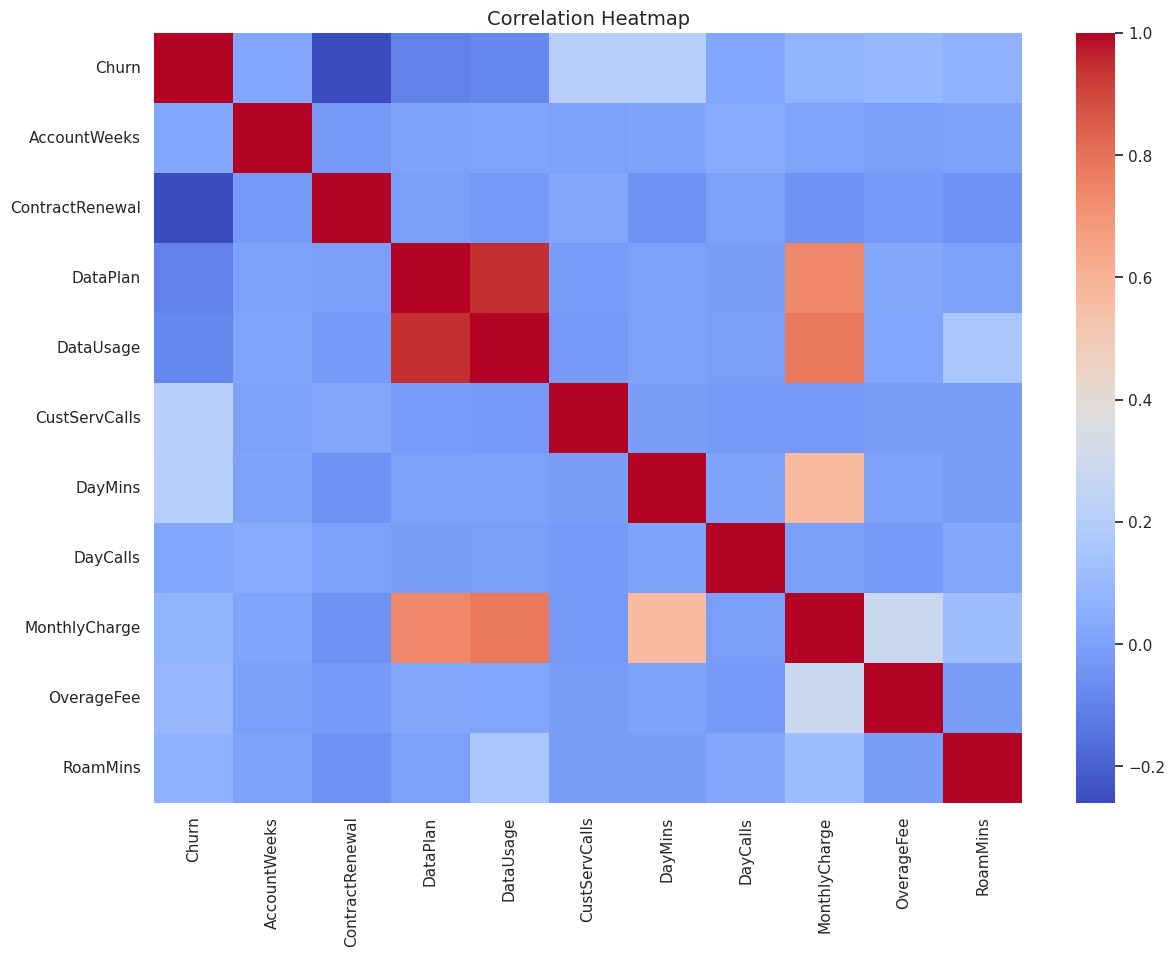

In [148]:
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [149]:
if target_col in corr.columns:
    churn_corr = corr[target_col].sort_values(ascending=False)
    churn_corr

In [151]:
df_fe = df.copy()

minute_cols = [col for col in usage_cols if col in df_fe.columns]
call_cols_existing = [col for col in call_cols if col in df_fe.columns]
charge_cols_existing = [col for col in charge_cols if col in df_fe.columns]

if minute_cols:
    df_fe["Total_Minutes"] = df_fe[minute_cols].sum(axis=1)

if call_cols_existing:
    df_fe["Total_Calls"] = df_fe[call_cols_existing].sum(axis=1)

if charge_cols_existing:
    df_fe["Total_Charges"] = df_fe[charge_cols_existing].sum(axis=1)

if "Total_Charges" in df_fe.columns and "Total_Minutes" in df_fe.columns:
    df_fe["Average_Charge_Per_Minute"] = df_fe["Total_Charges"] / df_fe["Total_Minutes"].replace(0, np.nan)
    df_fe["Average_Charge_Per_Minute"] = df_fe["Average_Charge_Per_Minute"].fillna(0)

if "Total_Minutes" in df_fe.columns:
    df_fe["High_Usage_Customer"] = (df_fe["Total_Minutes"] > df_fe["Total_Minutes"].median()).astype(int)

df_fe.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [155]:
engineered_cols = [
    "Total_Minutes", "Total_Calls", "Total_Charges",
    "Average_Charge_Per_Minute", "High_Usage_Customer"
]
engineered_cols = [col for col in engineered_cols if col in df_fe.columns]

for col in engineered_cols:
    if df_fe[col].nunique() <= 5:
        sns.countplot(data=df_fe, x=col, hue=target_col, palette="Set2")
    else:
        sns.boxplot(data=df_fe, x=target_col, y=col, palette="Set2")
    plt.title(f"{col} vs Churn")
    plt.show()

In [156]:
df_fe["Customer_Segment"] = "Regular Customer"

if "Total_Charges" in df_fe.columns:
    high_value_threshold = df_fe["Total_Charges"].quantile(0.75)
    df_fe.loc[df_fe["Total_Charges"] >= high_value_threshold, "Customer_Segment"] = "High Value Customer"

if "Total_Minutes" in df_fe.columns:
    heavy_usage_threshold = df_fe["Total_Minutes"].quantile(0.75)
    df_fe.loc[df_fe["Total_Minutes"] >= heavy_usage_threshold, "Customer_Segment"] = "Heavy User"

if service_cols:
    service_col = service_cols[0]
    df_fe.loc[df_fe[service_col] >= 4, "Customer_Segment"] = "High Risk Customer"

if "Account_Weeks" in df_fe.columns:
    loyal_threshold = df_fe["Account_Weeks"].quantile(0.75)
    df_fe.loc[df_fe["Account_Weeks"] >= loyal_threshold, "Customer_Segment"] = "Loyal Customer"

df_fe["Customer_Segment"].value_counts()

Customer_Segment
Regular Customer    3333
Name: count, dtype: int64

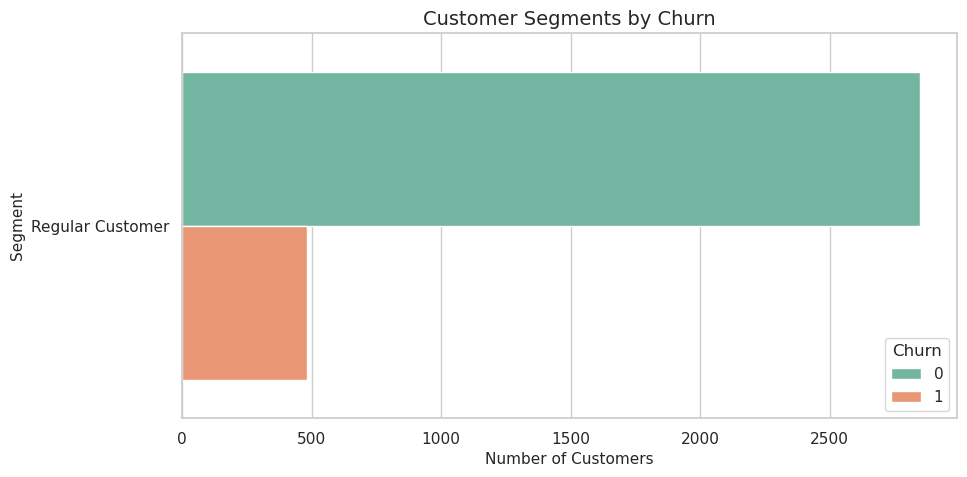

In [158]:
sns.countplot(data=df_fe, y="Customer_Segment", hue=target_col, palette="Set2")
plt.title("Customer Segments by Churn")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")
plt.show()

In [163]:
model_df = df_fe.copy()

for col in model_df.select_dtypes(include=["object", "category", "bool"]).columns:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))

X = model_df.drop(columns=[target_col])
y = model_df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 2666
Testing rows: 667


In [165]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

In [166]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9250

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       570
           1       0.81      0.63      0.71        97

    accuracy                           0.93       667
   macro avg       0.88      0.80      0.83       667
weighted avg       0.92      0.93      0.92       667



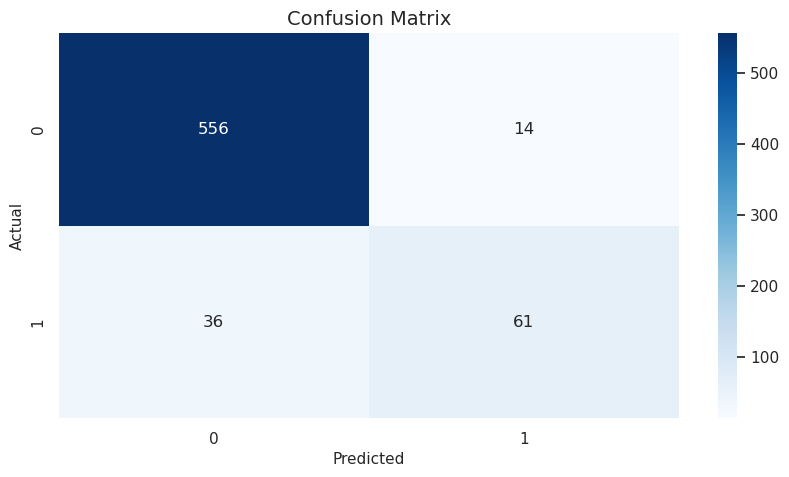

In [167]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [168]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
5,DayMins,0.179301
4,CustServCalls,0.177268
7,MonthlyCharge,0.167658
1,ContractRenewal,0.100408
8,OverageFee,0.082973
9,RoamMins,0.072399
0,AccountWeeks,0.063939
3,DataUsage,0.062927
6,DayCalls,0.061199
2,DataPlan,0.031927


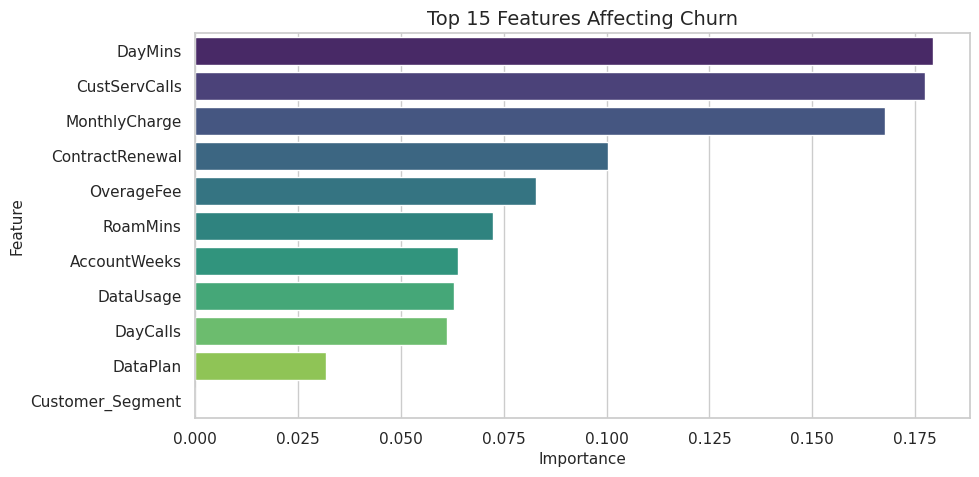

In [169]:
sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    palette="viridis"
)
plt.title("Top 15 Features Affecting Churn")
plt.show()

In [170]:
account_cols = [col for col in df_fe.columns if "Account" in col or "account" in col]
account_cols

['AccountWeeks']

Lifetime column used: AccountWeeks
Average customer lifetime: 101.06


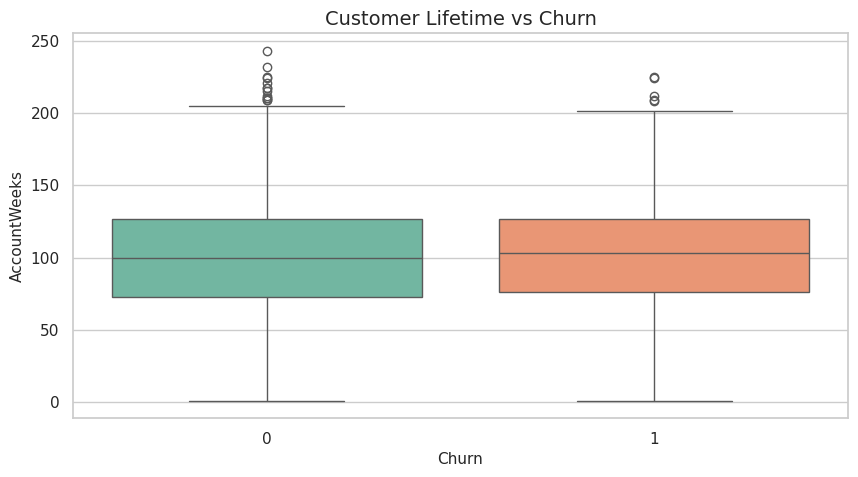

In [171]:
if account_cols:
    lifetime_col = account_cols[0]
    print("Lifetime column used:", lifetime_col)
    print("Average customer lifetime:", round(df_fe[lifetime_col].mean(), 2))

    sns.boxplot(data=df_fe, x=target_col, y=lifetime_col, palette="Set2")
    plt.title("Customer Lifetime vs Churn")
    plt.show()
else:
    print("No account lifetime column found.")

In [173]:
kpis = {
    "Total Customers": total_customers,
    "Churn Rate (%)": round(churn_rate, 2),
    "Retention Rate (%)": round(retention_rate, 2),
}

if "Total_Charges" in df_fe.columns:
    kpis["Average Revenue"] = round(df_fe["Total_Charges"].mean(), 2)

if "Total_Minutes" in df_fe.columns:
    kpis["Average Usage Minutes"] = round(df_fe["Total_Minutes"].mean(), 2)

if account_cols:
    kpis["Average Lifetime"] = round(df_fe[account_cols[0]].mean(), 2)

if service_cols:
    kpis["Average Customer Service Calls"] = round(df_fe[service_cols[0]].mean(), 2)

kpi_df = pd.DataFrame(kpis.items(), columns=["KPI", "Value"])
kpi_df

,KPI,Value
0,Total Customers,3333.00
1,Churn Rate (%),14.49
2,Retention Rate (%),85.51
3,Average Lifetime,101.06


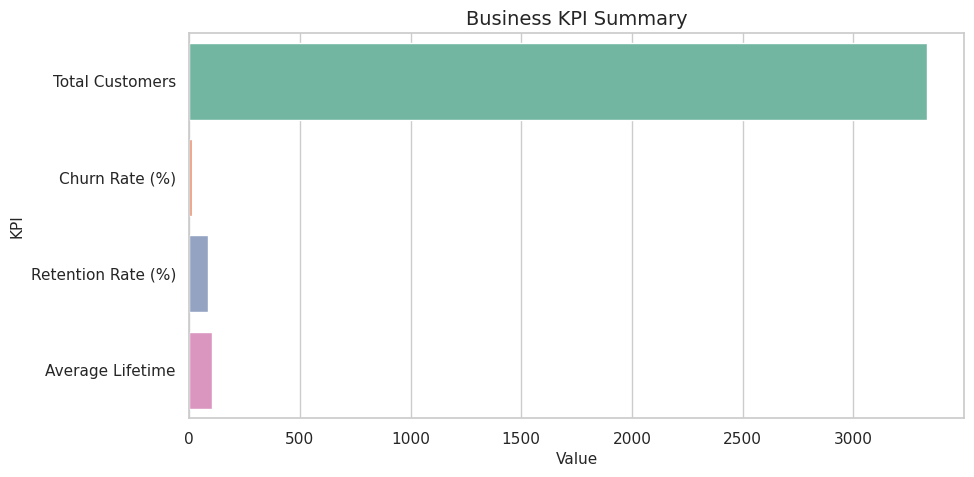

In [175]:
sns.barplot(data=kpi_df, x="Value", y="KPI", palette="Set2")
plt.title("Business KPI Summary")
plt.show()

Business Insights
Customer churn is an important business issue because it directly affects recurring revenue.
Customers with frequent customer service calls should be treated as high-risk customers.
Plan-related variables such as international plan and voice mail plan can influence churn behavior.
High usage customers may churn if pricing or service quality does not match their expectations.
Revenue-related features help identify valuable customers who should be prioritized for retention.
Service usage patterns reveal differences between retained and churned customers.
Customers with higher total charges can represent either high value or high dissatisfaction risk.
Customer lifetime helps separate loyal customers from newer customers.
Segmentation helps the business create targeted retention campaigns instead of using one common strategy.
Machine learning can support early churn detection and proactive customer engagement.
Feature importance helps business teams understand the strongest churn drivers.
High-risk customers should be contacted before they cancel the service.
Loyal customers can be rewarded to increase long-term retention.
Churn prediction should be updated regularly with new customer data.
Combining data analysis with business action can reduce churn and improve profitability.

Recommendations
Improve customer support quality, especially for customers making repeated service calls.
Create proactive retention campaigns for customers predicted as high risk.
Offer loyalty benefits to long-term customers.
Review pricing for high-usage and high-charge customers.
Provide special support for customers with international plans.
Monitor service complaints and resolve them quickly.
Use customer segmentation to personalize offers.
Build a dashboard to track churn rate, retention rate, revenue, and customer risk.
Retrain the model periodically using updated telecom customer data.
Combine churn prediction with marketing campaigns to reduce customer loss.

Conclusion
This project analyzed telecom customer churn using data cleaning, exploratory analysis, customer segmentation, feature engineering, and machine learning. The Random Forest model was used to predict churn and identify the most important factors influencing customer loss.
The analysis shows that churn can be reduced by improving customer support, identifying high-risk customers early, and creating targeted retention strategies. These insights can help a telecom company improve customer satisfaction, reduce revenue loss, and increase long-term customer value.